# Анализ маршрутов пациентов и факторов, связанных с экстренной госпитализацией пациентов

## Цель проекта

Оценить маршруты пациентов между поликлиникой, скорой медицинской помощью и круглосуточным стационаром, а также определить факторы и группы заболеваний, связанные с экстренной госпитализацией.

## Задачи

1. Подготовить и проверить исходные таблицы: обращения, разовые посещения, госпитализации и вызовы СМП.
2. Привести диагнозы к классам МКБ-10 и сформировать единые признаки для сравнения источников.
3. Описать распределение нагрузки по возрасту, диагнозам, профилям помощи и источникам данных.
4. Выделить экстренные госпитализации и оценить их долю среди госпитализаций круглосуточного стационара.
5. Проверить, были ли перед экстренной госпитализацией обращения в поликлинику или вызовы СМП по той же группе диагнозов.
6. Оценить сезонность нагрузки и группы риска экстренной госпитализации по классам МКБ-10.
7. Сравнить плановые и экстренные госпитализации по возрасту, летальности, структуре диагнозов и длительности лечения.
8. Отдельно детализировать структуру госпитализаций по болезням системы кровообращения (`I00-I99`).

## Оглавление

1. Подготовка и проверка данных
2. Распределения нагрузки
3. Экстренные госпитализации
4. Контакт с поликлиникой перед экстренной госпитализацией
5. Динамика и сезонность нагрузки
6. Группы риска экстренной госпитализации по диагнозам
7. Вызовы СМП перед экстренной госпитализацией
8. Плановые и экстренные госпитализации: возраст, летальность, структура диагнозов и длительность лечения
9. Детализация госпитализаций `I00-I99`
10. Сравнение длительности пребывания в стационаре после плановой и экстренной госпитализации
11. Итоговые выводы

## 1. Подготовка и проверка данных

In [1]:
import re
from datetime import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
from google.colab import drive

drive.mount('/content/drive')

cases = pd.read_excel('/content/drive/MyDrive/обращения.xlsx')
visits = pd.read_excel('/content/drive/MyDrive/посещения_разовые.xlsx')
hospital = pd.read_excel('/content/drive/MyDrive/стационар.xlsx')
ambulance = pd.read_excel('/content/drive/MyDrive/СМП.xlsx')

Mounted at /content/drive


In [3]:
# cases = pd.read_excel(r"C:\Users\artem\OneDrive\Рабочий стол\для проекта\аноним\обращения.xlsx")
# visits = pd.read_excel(r"C:\Users\artem\OneDrive\Рабочий стол\для проекта\аноним\посещения_разовые.xlsx")
# hospital = pd.read_excel(r"C:\Users\artem\OneDrive\Рабочий стол\для проекта\аноним\стационар.xlsx")
# ambulance = pd.read_excel(r"C:\Users\artem\OneDrive\Рабочий стол\для проекта\аноним\СМП.xlsx")

In [4]:
cases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39027 entries, 0 to 39026
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    39027 non-null  object        
 1   age           39027 non-null  int64         
 2   death_date    700 non-null    datetime64[ns]
 3   visits_count  39027 non-null  int64         
 4   start_date    39027 non-null  datetime64[ns]
 5   end_date      39027 non-null  datetime64[ns]
 6   diagnosis     38928 non-null  object        
 7   doc_id        39027 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(3)
memory usage: 2.4+ MB


Таблица с обращениями по заболеванию. Одно обращение предполагает 2 и более посещений. Есть пропущенные значения по полю Диагноз. Их немного - удаляю эти строки.



In [5]:
cases = cases.dropna(subset=['diagnosis'])

In [6]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51108 entries, 0 to 51107
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   patient_id  51108 non-null  object        
 1   age         51108 non-null  int64         
 2   death_date  1281 non-null   datetime64[ns]
 3   diagnosis   51108 non-null  object        
 4   department  51108 non-null  object        
 5   doc_id      51108 non-null  object        
 6   visit_date  51108 non-null  datetime64[ns]
 7   location    51108 non-null  object        
 8   specialty   51108 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 3.5+ MB


Таблица с посещениями по заболеванию. Пропущенные значения по полю Дата смерти это нормально.

In [7]:
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12650 entries, 0 to 12649
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   patient_id     12650 non-null  object        
 1   age            12650 non-null  int64         
 2   death_date     1084 non-null   datetime64[ns]
 3   hosp_date      12650 non-null  datetime64[ns]
 4   end_date       12650 non-null  datetime64[ns]
 5   diagnosis      12650 non-null  object        
 6   department     12650 non-null  object        
 7   profile        12650 non-null  object        
 8   hospital_days  12650 non-null  int64         
 9   location       12650 non-null  object        
 10  outcome        12650 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(6)
memory usage: 1.1+ MB


Таблица с госпитализациями и обращениями в приемное отделение.

In [8]:
hospital['location'].unique()

array(['стационар', 'дневной стационар', 'приемное отделение'],
      dtype=object)

In [9]:
ambulance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10022 entries, 0 to 10021
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   дата_вызова               10022 non-null  object 
 1   время_вызова              10022 non-null  object 
 2   время_передачи_вызова     9750 non-null   object 
 3   возраст                   10022 non-null  int64  
 4   повод_вызова              10022 non-null  object 
 5   диагноз                   9588 non-null   object 
 6   помощь/направление        9750 non-null   object 
 7   состав_бригады            9749 non-null   object 
 8   выезд_на_вызов            9750 non-null   object 
 9   окончание_вызова          9750 non-null   object 
 10  длительность_вызова       9750 non-null   object 
 11  время_доезда              9749 non-null   object 
 12  вызов_выезд_длительность  9750 non-null   float64
 13  patient_id                10022 non-null  object 
dtypes: flo

Таблица с вызовами скорой помощи. Есть пропуски в поле *Диагноз* - заполню значением *Неизвестно*.

In [10]:
# ambulance['диагноз'].isna().sum()
ambulance.loc[ambulance['диагноз'].isna(), 'диагноз'] = 'Неизвестно'

In [11]:
ambulance['диагноз'].head(1)

,диагноз
0,Основной: J44.9. Хроническая обструктивная лег...


In [12]:
# проверка формата записи диагноза
ambulance['диагноз'].apply(lambda x: x[:3]).unique()

array(['Осн', 'Неи'], dtype=object)

In [13]:
def clean_diag(x):

    if x != "Неизвестно":
        # Находим первую латинскую букву и берём всё от неё до конца строки
        x = re.sub(r'^[^a-zA-Z]*', '', x)

    return x

In [14]:
ambulance['диагноз'] = ambulance['диагноз'].apply(clean_diag)

In [15]:
# ambulance['диагноз'].apply(lambda x: x[:3]).unique()

В таблицу *cases* добавлю поле *specialty*, чтобы понимать к врачу какой специальности обращался пациент.

In [16]:
# врачи с 2 и более специализациями
docs_specs = visits.groupby('doc_id')['specialty'].unique()
docs_specs[docs_specs.apply(len) > 1]

,specialty
doc_id,
035ca96ddbccc05c,"[терапия, педиатрия]"
10a0f1ff5899d283,"[терапия, педиатрия]"
1eebbd32b530e310,"[терапия, педиатрия]"
5650a30bed4d0c03,"[педиатрия, неврология]"
61dcefaee1aeba00,"[инфекционные болезни, реабилитация]"
6727c822a4eb676c,"[терапия, педиатрия]"
9d8aee45df927955,"[педиатрия, терапия]"
d3d67b1cbaa1b7a2,"[терапия, педиатрия]"
f02e81b4733e591e,"[терапия, педиатрия]"


In [17]:
docs_2specs = docs_specs[docs_specs.apply(len) > 1].index.tolist()
docs_1spec = (docs_specs[docs_specs.apply(len) == 1]).str[0]

In [18]:
def create_specs(doc, diagnosis, age):
    """
    Определяет врачебную специальность по врачу, диагнозу и возрасту пациента.

    Логика:
    - Для врачей с одной специальностью используется справочник docs_1spec.
    - Для врачей, работающих по нескольким профилям (docs_2specs),
      специальность определяется по дополнительным правилам:
        * для врача 61dcefaee1aeba00:
            - диагнозы классов M и S -> реабилитация;
            - остальные случаи -> инфекционные болезни.
        * для врача 5650a30bed4d0c03:
            - диагнозы класса G -> неврология;
            - остальные случаи -> педиатрия.
        * для врачей общей практики:
            - взрослые (>=18 лет) -> терапия;
            - дети (<18 лет) -> педиатрия.

    Возвращает:
        str | None: название специальности или None,
        если врач отсутствует в справочниках.
    """
    diagnosis = str(diagnosis)

    if doc in docs_2specs:

        if doc == '61dcefaee1aeba00':

            if diagnosis[0] in ['M', 'S']: # диагнозы по реабилитации
                return 'реабилитация'

            return 'инфекционные болезни' # также это врач-инфекционист

        elif doc == '5650a30bed4d0c03':

            if diagnosis[0] == 'G':
                return 'неврология' # диагнозы по неврологии

            return 'педиатрия' # также это врач-педиатр

        else:

            if age >= 18:            # врачи/фельдшеры общей практики, которые принимают взрослых и детей
                return 'терапия'

            return 'педиатрия'

    elif doc in docs_1spec:

        return docs_1spec[doc]

    return None

In [19]:
cases['specialty'] = cases.apply(
    lambda row: create_specs(
        row['doc_id'],
        row['diagnosis'],
        row['age']
    ),
    axis=1
)

In [20]:
cases.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38928 entries, 0 to 39026
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    38928 non-null  object        
 1   age           38928 non-null  int64         
 2   death_date    696 non-null    datetime64[ns]
 3   visits_count  38928 non-null  int64         
 4   start_date    38928 non-null  datetime64[ns]
 5   end_date      38928 non-null  datetime64[ns]
 6   diagnosis     38928 non-null  object        
 7   doc_id        38928 non-null  object        
 8   specialty     38927 non-null  object        
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


In [21]:
cases.loc[cases['specialty'].isna()]
cases = cases.dropna(subset=['specialty'])

Один пропуск, можно удалить

In [22]:
def icd_chapter(diagnosis):
    """
    Определяет главу (диапазон кодов) Международной классификации болезней (МКБ) по коду диагноза.

    Функция принимает код диагноза в виде строки (например, 'C34', 'E11', 'H61') и возвращает
    строковое обозначение соответствующей главы МКБ (например, 'C00-D48', 'E00-E90').
    Если формат кода не соответствует ожидаемому или код не распознан, возвращает 'Unknown'.

    Алгоритм работы:
    1.  Приводит входное значение к строке и верхнему регистру.
    2.  С помощью регулярного выражения извлекает букву (A-Z) и двузначное число.
    3.  На основе извлеченной буквы и числового значения определяет диапазон главы МКБ.
       Некоторые главы (например, D, H) имеют несколько диапазонов, которые разделены по числовому значению.

    """
    match = re.search(r'([A-Z])\s*(\d{2})', str(diagnosis).upper())

    if not match:
        return 'Unknown'

    letter = match.group(1)
    num = int(match.group(2))

    if letter in ['A', 'B']:
        return 'A00-B99'

    if letter == 'C' or (letter == 'D' and num <= 48):
        return 'C00-D48'

    if letter == 'D' and num >= 50:
        return 'D50-D89'

    if letter == 'E':
        return 'E00-E90'

    if letter == 'F':
        return 'F00-F99'

    if letter == 'G':
        return 'G00-G99'

    if letter == 'H' and num <= 59:
        return 'H00-H59'

    if letter == 'H' and num >= 60:
        return 'H60-H95'

    if letter == 'I':
        return 'I00-I99'

    if letter == 'J':
        return 'J00-J99'

    if letter == 'K':
        return 'K00-K93'

    if letter == 'L':
        return 'L00-L99'

    if letter == 'M':
        return 'M00-M99'

    if letter == 'N':
        return 'N00-N99'

    if letter == 'O':
        return 'O00-O99'

    if letter == 'P':
        return 'P00-P96'

    if letter == 'Q':
        return 'Q00-Q99'

    if letter == 'R':
        return 'R00-R99'

    if letter in ['S', 'T']:
        return 'S00-T98'

    if letter in ['V', 'W', 'X', 'Y']:
        return 'V01-Y98'

    if letter == 'Z':
        return 'Z00-Z99'

    if letter == 'U':
        return 'U00-U99'

    return 'Unknown'


icd_names = {
    'A00-B99': 'Инфекционные и паразитарные болезни',
    'C00-D48': 'Новообразования',
    'D50-D89': 'Болезни крови и иммунные нарушения',
    'E00-E90': 'Эндокринные болезни',
    'F00-F99': 'Психические расстройства',
    'G00-G99': 'Болезни нервной системы',
    'H00-H59': 'Болезни глаза',
    'H60-H95': 'Болезни уха',
    'I00-I99': 'Болезни системы кровообращения',
    'J00-J99': 'Болезни органов дыхания',
    'K00-K93': 'Болезни органов пищеварения',
    'L00-L99': 'Болезни кожи',
    'M00-M99': 'Болезни костно-мышечной системы',
    'N00-N99': 'Болезни мочеполовой системы',
    'O00-O99': 'Беременность, роды и послеродовой период',
    'P00-P96': 'Состояния перинатального периода',
    'Q00-Q99': 'Врожденные аномалии',
    'R00-R99': 'Симптомы и отклонения от нормы',
    'S00-T98': 'Травмы и отравления',
    'V01-Y98': 'Внешние причины',
    'Z00-Z99': 'Факторы обращения за медпомощью',
    'U00-U99': 'Коды для особых целей',
    'Unknown': 'Неизвестно'
}

In [23]:
cases['icd_group'] = cases['diagnosis'].apply(icd_chapter)
visits['icd_group'] = visits['diagnosis'].apply(icd_chapter)
hospital['icd_group'] = hospital['diagnosis'].apply(icd_chapter)
ambulance['icd_group'] = ambulance['диагноз'].apply(icd_chapter)

cases['icd_name'] = cases['icd_group'].map(icd_names)
visits['icd_name'] = visits['icd_group'].map(icd_names)
hospital['icd_name'] = hospital['icd_group'].map(icd_names)
ambulance['icd_name'] = ambulance['icd_group'].map(icd_names)

## 2. Распределения нагрузки

### 2.1 Поликлиника: возраст, класс МКБ и профиль

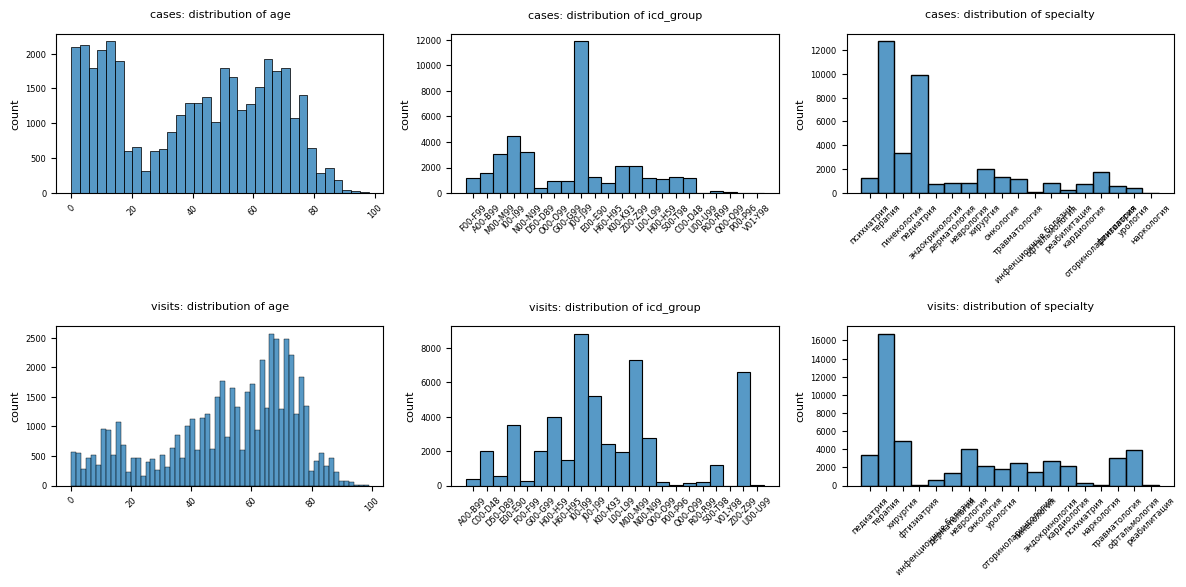

In [24]:
features = ['age', 'icd_group', 'specialty'] * 2

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))
axs = axs.flatten()

for i, col in enumerate(features):

    ax = axs[i]

    if i < 3:
        data = 'cases'
        sns.histplot(
            cases,
            x=cases[col],
            ax=ax
        )

    else:
        data = 'visits'
        sns.histplot(
            visits,
            x=visits[col],
            ax=ax
        )

    ax.set_xlabel('')
    ax.set_ylabel('count', size=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(
    '{}: distribution of {}'.format(data, col), size=8, y=1.05
    )

plt.tight_layout()
plt.show()

- Основную нагрузку на амбулаторное звено создают дети и люди старше 40
- Большинство диагнозов встречаются редко, но небольшое число классов создаёт основной поток пациентов (I, J, H, M). Z - профилактические посещения (осмотры, вакцинации, консультации)
- Основная нагрузка приходится на базовые специальности (терапия, педиатрия). Это первичное звено мед помощи

### 2.2 Круглосуточный стационар: возраст, класс МКБ и профиль

Поскольку для дальнейшего анализа используются данные по круглосуточному стационару, распределение ниже рассчитано только по нему.

In [25]:
# только круглосуточный стационар
main_hospital = hospital.loc[hospital['location'] == 'стационар']

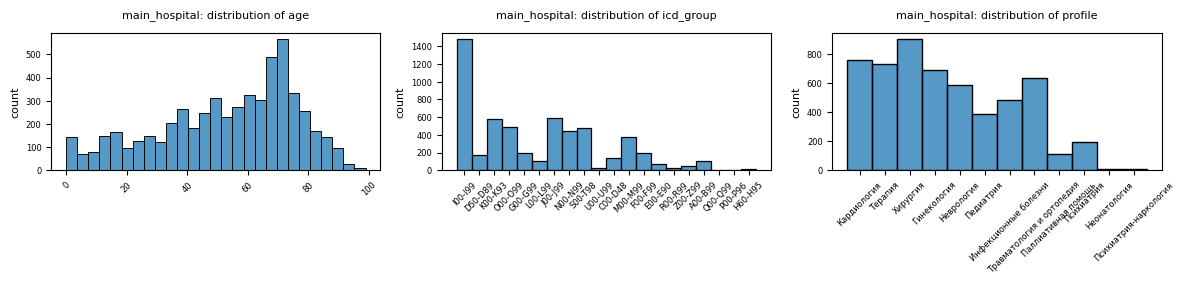

In [26]:
features_hosp = ['age', 'icd_group', 'profile']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
axs = axs.flatten()

for i, col in enumerate(features_hosp):

    ax = axs[i]

    sns.histplot(
        main_hospital,
        x=main_hospital[col],
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('count', size=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(
    'main_hospital: distribution of {}'.format(col), size=8, y=1.05
    )

plt.tight_layout()
plt.show()


*   В основном в больнице лечатся пожилые люди 60-75 лет
*   Самая частая группа диагнозов - болезни системы кровообращения (I)
*   По профилю помощи больше всего пациентов пролечилось в хирургии. Выделяются 4 профиля с наименьшим числом пациентов (паллиативная помощь, психиатрия, неонатология). По наркологии данные не полные, поэтому в расчет не беру.





### 2.3 Скорая медицинская помощь: возраст и классы МКБ-10

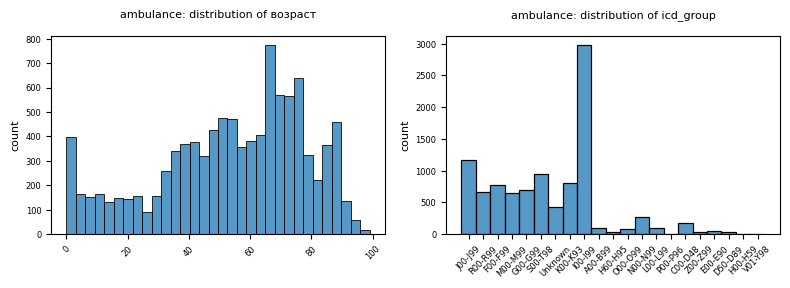

In [27]:
ambulance_features = ['возраст', 'icd_group']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

for i, col in enumerate(ambulance_features):

    ax = axs[i]

    sns.histplot(
        ambulance,
        x=ambulance[col],
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('count', size=8)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(
        'ambulance: distribution of {}'.format(col), size=8, y=1.05
    )

plt.tight_layout()
plt.show()

- Люди до 30 лет реже вызывают скорую. Основную нагрузку на СМП создают люди 60-80 лет
- Чаще всего поводом для вызова скорой являются сердечно-сосудистые болезни (I00-99)

## 3. Экстренные госпитализации

### 3.1 Определение экстренной госпитализации

Экстренная госпитализация определяется как госпитализация в круглосуточный стационар после вызова СМП в день госпитализации. Дополнительно учитываются случаи, когда вызов был поздно вечером, а госпитализация произошла после полуночи.

In [28]:
# привидение типов данных
ambulance['дата_вызова'] = pd.to_datetime(ambulance['дата_вызова'], format='%d.%m.%Y', errors='coerce')
time_amb = ['время_вызова', 'время_передачи_вызова', 'выезд_на_вызов', 'окончание_вызова', 'время_доезда']
ambulance[time_amb] = ambulance[time_amb].apply(lambda col: pd.to_datetime(col, format='%H:%M:%S', errors='coerce').dt.time)
ambulance['вызов_выезд_длительность'] = ambulance['вызов_выезд_длительность'].astype('Int64')
ambulance['длительность_вызова'] = pd.to_datetime(ambulance['длительность_вызова'], format='%H:%M', errors='coerce').dt.time

In [29]:
ambulance['длительность_вызова'] = pd.to_timedelta(
        ambulance['длительность_вызова'].astype(str)
    ).dt.total_seconds() / 60

In [30]:
ambulance['длительность_вызова'].quantile(0.95)

np.float64(82.0)

Длительность 95% вызовов составила менее 82 минут. Поэтому для вызовов, начавшихся с 22:30 по 00:00, буду смотреть госпитализацию не только в день вызова, но и на следующий день.

In [31]:
ambulance.head(1)

,дата_вызова,время_вызова,время_передачи_вызова,возраст,повод_вызова,диагноз,помощь/направление,состав_бригады,выезд_на_вызов,окончание_вызова,длительность_вызова,время_доезда,вызов_выезд_длительность,patient_id,icd_group,icd_name
0,2025-01-01,00:43:00,00:43:00,51,05А.Задыхается (бронхиальная астма),J44.9. Хроническая обструктивная легочная боле...,"Оказана помощь, больной оставлен на месте","Один фельдшер, Водитель",00:44:00,01:04:00,21.0,00:47:00,1,2e7acb848299aa87,J00-J99,Болезни органов дыхания


In [32]:
# Создаём дополнительную дату +1 день
ambulance['next_date'] = ambulance['дата_вызова'] + pd.Timedelta(days=1)

In [33]:
late_time = (
    (ambulance['время_вызова'] >= time(22, 30)) &
    (ambulance['время_вызова'] <= time(23, 59))
)

In [34]:
# госпитализация в день вызова скорой
same_day = ambulance[['patient_id', 'дата_вызова']].merge(
    main_hospital,
    left_on=['patient_id', 'дата_вызова'],
    right_on=['patient_id', 'hosp_date'],
    how='inner'
)

In [35]:
same_day.shape[0]

1973

In [36]:
# госпитализация на следующий день, когда скорая вызывалась с 22:30 до 23:59
next_day = ambulance.loc[late_time, ['patient_id', 'next_date']].merge(
    main_hospital,
    left_on=['patient_id', 'next_date'],
    right_on=['patient_id', 'hosp_date'],
    how='inner'
)

In [37]:
next_day.shape[0]

68

In [38]:
# экстренные госпитализации
emergency_hosps = pd.concat([same_day, next_day], ignore_index=True)

In [39]:
emergency_hosps.head(1)

,patient_id,дата_вызова,age,death_date,hosp_date,end_date,diagnosis,department,profile,hospital_days,location,outcome,icd_group,icd_name,next_date
0,0f70637b62c0d28c,2025-01-01,69,NaT,2025-01-01,2025-01-10,S22.4. Множественные переломы ребер,Травматология стац.,Травматология и ортопедия,9,стационар,Выписан,S00-T98,Травмы и отравления,NaT


In [40]:
print(f"Экстренные госпитализации: {emergency_hosps.shape[0]}")

Экстренные госпитализации: 2041


In [41]:
print(f"Экстренные госпитализации, доля: {round(emergency_hosps.shape[0] / main_hospital.shape[0], 2)}")

Экстренные госпитализации, доля: 0.37


Из общего числа госпитализаций экстренных - **37%**

## 4. Контакт с поликлиникой перед экстренной госпитализацией

Проверяется, были ли у пациента обращения в поликлинику за 5 дней или меньше до экстренной госпитализации по той же группе диагнозов. `cases` учитывается как интервал обращения от `start_date` до `end_date`, `visits` - как разовый визит по `visit_date`.

In [42]:
win = pd.Timedelta(days=5)

cases_eh = cases.merge(emergency_hosps, on=['patient_id', 'icd_group'])

cases_eh = cases_eh.loc[
    (cases_eh['start_date'] <= cases_eh['hosp_date']) &
    (cases_eh['end_date_x'] >= cases_eh['hosp_date'] - win)
].copy()

cases_eh['source'] = 'cases'
cases_eh['contact_date'] = cases_eh[['end_date_x', 'hosp_date']].min(axis=1)
cases_eh['days_before_hosp'] = (
    cases_eh['hosp_date'] - cases_eh['contact_date']
).dt.days


visits_eh = visits.merge(emergency_hosps, on=['patient_id', 'icd_group'])

visits_eh['days_before_hosp'] = (
    visits_eh['hosp_date'] - visits_eh['visit_date']
).dt.days

visits_eh = visits_eh.loc[visits_eh['days_before_hosp'].between(0, 5)].copy()

visits_eh['source'] = 'visits'
visits_eh['contact_date'] = visits_eh['visit_date']


cols = [
    'patient_id', 'hosp_date', 'source', 'contact_date',
    'icd_group', 'specialty', 'days_before_hosp'
]

poly_before_emerg = (
    pd.concat([cases_eh[cols], visits_eh[cols]], ignore_index=True)
      .sort_values('days_before_hosp')
      .drop_duplicates(['patient_id', 'hosp_date'])
      .reset_index(drop=True)
)

In [43]:
poly_before_emerg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   patient_id        326 non-null    object        
 1   hosp_date         326 non-null    datetime64[ns]
 2   source            326 non-null    object        
 3   contact_date      326 non-null    datetime64[ns]
 4   icd_group         326 non-null    object        
 5   specialty         326 non-null    object        
 6   days_before_hosp  326 non-null    int64         
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 18.0+ KB


In [44]:
print(
    f'Пациенты, обращавшиеся в поликлинику в период 5 дней до экстренной '
    f'госпитализации по одному классу болезней: {poly_before_emerg.shape[0]}')

Пациенты, обращавшиеся в поликлинику в период 5 дней до экстренной госпитализации по одному классу болезней: 326


In [45]:
(
    poly_before_emerg['icd_group']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)[:5]

,proportion
icd_group,
I00-I99,37.4
J00-J99,16.9
M00-M99,7.4
N00-N99,7.1
K00-K93,6.7


Более трети пациентов с сердечно-сосудистыми заболеваниями (I00-I99)

In [46]:
round(len(poly_before_emerg) / len(emergency_hosps), 2)

0.16

Доля госпитализаций с посещением поликлиники в период 5 дней до экстренной госпитализации по тому же классу заболевания - **16%**

## 5. Динамика и сезонность нагрузки

Ниже сравнивается помесячная нагрузка по обращениям, разовым посещениям, госпитализациям круглосуточного стационара и вызовам СМП.

In [47]:
load_sources = {
    'cases': (cases, 'end_date'),
    'visits': (visits, 'visit_date'),
    'main_hospital': (main_hospital, 'end_date'),
    'ambulance': (ambulance, 'дата_вызова'),
}

source_order = list(load_sources.keys())
month_names = {
    1: 'янв', 2: 'фев', 3: 'мар', 4: 'апр',
    5: 'май', 6: 'июн', 7: 'июл', 8: 'авг',
    9: 'сен', 10: 'окт', 11: 'ноя', 12: 'дек'
}

monthly_parts = []

for source, (df, date_col) in load_sources.items():
    tmp = df[[date_col]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors='coerce')
    tmp = tmp.dropna(subset=[date_col])

    if tmp.empty:
        continue

    month_range = pd.period_range(
        tmp[date_col].min().to_period('M'),
        tmp[date_col].max().to_period('M'),
        freq='M'
    )

    monthly = (
        tmp.assign(month=tmp[date_col].dt.to_period('M'))
           .groupby('month')
           .size()
           .reindex(month_range, fill_value=0)
           .rename('load')
           .reset_index()
           .rename(columns={'index': 'month'})
    )

    monthly['source'] = source
    monthly['month_start'] = monthly['month'].dt.to_timestamp()
    monthly['year'] = monthly['month'].dt.year
    monthly['month_num'] = monthly['month'].dt.month
    monthly['month_name'] = monthly['month_num'].map(month_names)
    monthly_parts.append(monthly)

monthly_load = pd.concat(monthly_parts, ignore_index=True)
monthly_load['source'] = pd.Categorical(
    monthly_load['source'], categories=source_order, ordered=True
)

monthly_load.head()


,month,load,source,month_start,year,month_num,month_name
0,2025-01,2707,cases,2025-01-01,2025,1,янв
1,2025-02,4174,cases,2025-02-01,2025,2,фев
2,2025-03,3764,cases,2025-03-01,2025,3,мар
3,2025-04,3555,cases,2025-04-01,2025,4,апр
4,2025-05,2825,cases,2025-05-01,2025,5,май


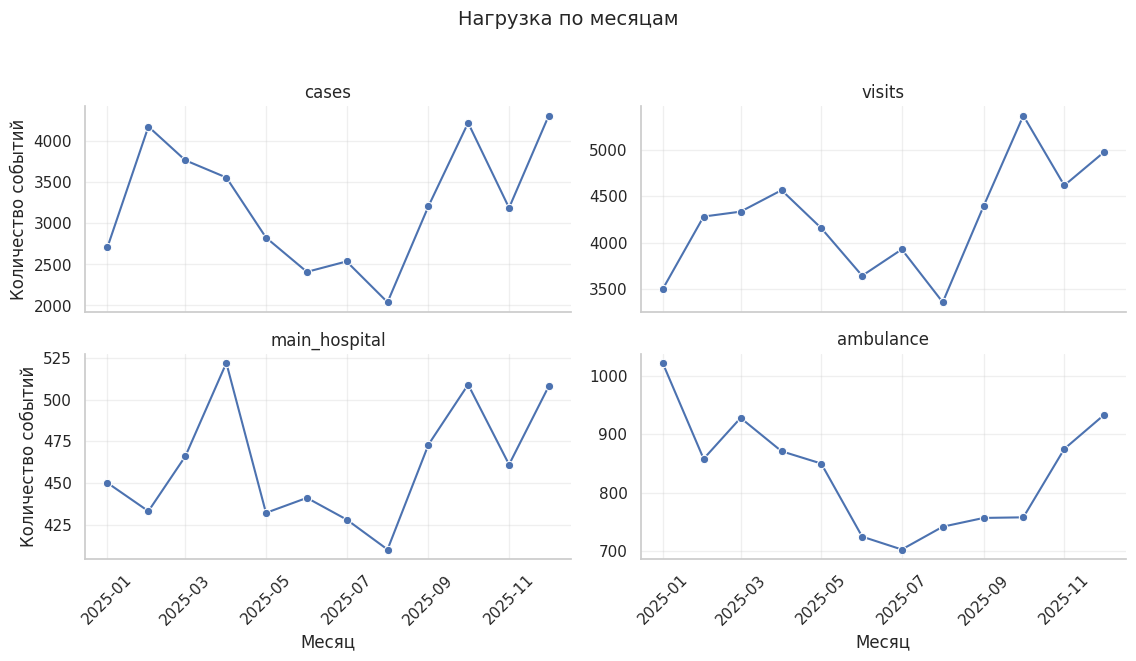

In [48]:
sns.set_theme(style='whitegrid')

monthly_plot = sns.relplot(
    data=monthly_load,
    x='month_start',
    y='load',
    col='source',
    col_wrap=2,
    kind='line',
    marker='o',
    height=3.2,
    aspect=1.8,
    facet_kws={'sharey': False}
)

monthly_plot.set_axis_labels('Месяц', 'Количество событий')
monthly_plot.set_titles('{col_name}')

for ax in monthly_plot.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

monthly_plot.fig.suptitle('Нагрузка по месяцам', y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


По всем видам мед помощи нагрузка снижается в летние месяцы. Это может быть связано с отпускным периодом как мед работников, так и пациентов. Высокая нагрузка отмечается в конце года, а по СМП еще и в начале года.

In [49]:
seasonality = (
    monthly_load
    .groupby(['source', 'month_num'], observed=True)['load']
    .mean()
    .reset_index(name='avg_month_load')
)

source_avg_load = (
    monthly_load
    .groupby('source', observed=True)['load']
    .mean()
    .rename('avg_source_load')
    .reset_index()
)

seasonality = seasonality.merge(source_avg_load, on='source', how='left')
seasonality['seasonality_factor'] = (
    seasonality['avg_month_load'] / seasonality['avg_source_load']
)
seasonality['month_name'] = seasonality['month_num'].map(month_names)
seasonality['source'] = pd.Categorical(
    seasonality['source'], categories=source_order, ordered=True
)

seasonality_pivot = (
    seasonality
    .pivot(index='month_num', columns='source', values='seasonality_factor')
    .rename(index=month_names)
)

seasonality_pivot.round(2)


source,cases,visits,main_hospital,ambulance
month_num,,,,
янв,0.83,0.82,0.98,1.22
фев,1.29,1.00,0.94,1.03
мар,1.16,1.02,1.01,1.11
апр,1.10,1.07,1.13,1.04
май,0.87,0.98,0.94,1.02
июн,0.74,0.86,0.96,0.87
июл,0.78,0.92,0.93,0.84
авг,0.63,0.79,0.89,0.89
сен,0.99,1.03,1.03,0.91


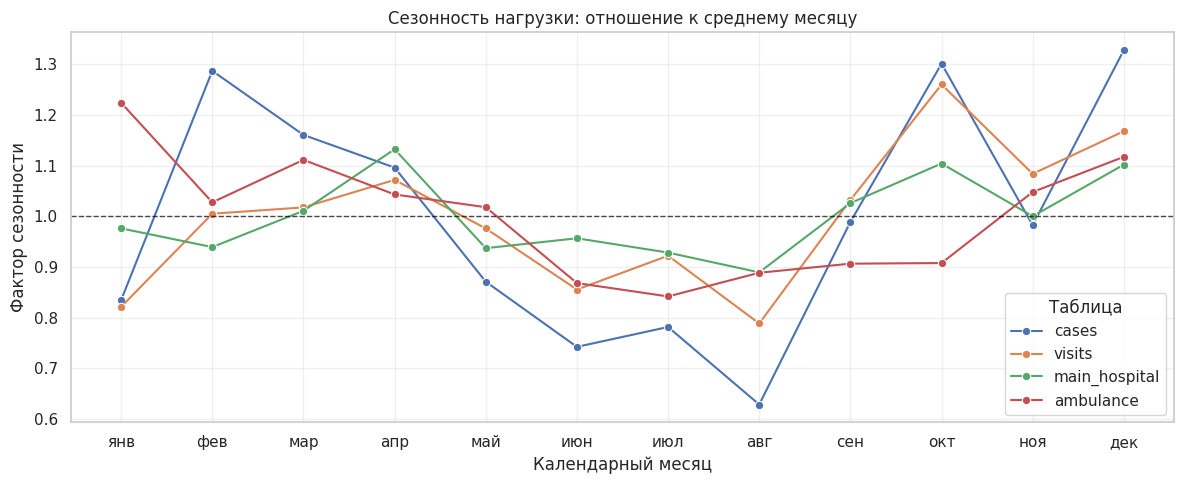

In [50]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=seasonality,
    x='month_num',
    y='seasonality_factor',
    hue='source',
    marker='o',
    ax=ax
)

ax.axhline(1, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[i] for i in range(1, 13)])
ax.set_xlabel('Календарный месяц')
ax.set_ylabel('Фактор сезонности')
ax.set_title('Сезонность нагрузки: отношение к среднему месяцу')
ax.legend(title='Таблица')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Анализ сезонности показал наличие выраженных календарных колебаний нагрузки во всех медицинских службах. Минимальные значения наблюдаются преимущественно в летние месяцы (июнь–август), тогда как максимальная нагрузка приходится на осенне-зимний период (октябрь–декабрь). Наиболее выраженная сезонность характерна для амбулаторных обращений (cases), где объём нагрузки в декабре превышает средний месячный уровень на 32%, а в августе составляет лишь 63% от среднего. Госпитализации характеризуются существенно меньшей амплитудой колебаний и более равномерным распределением нагрузки в течение года. Это свидетельствует о более высокой чувствительности амбулаторного звена к сезонным факторам по сравнению со стационарной помощью.

In [51]:
seasonality_summary = (
    seasonality
    .sort_values(['source', 'seasonality_factor'], ascending=[True, False])
    .groupby('source', observed=True)
    .head(3)
    [['source', 'month_name', 'seasonality_factor', 'avg_month_load']]
    .reset_index(drop=True)
)

seasonality_summary


,source,month_name,seasonality_factor,avg_month_load
0,cases,дек,1.327716,4307.0
1,cases,окт,1.300897,4220.0
2,cases,фев,1.286716,4174.0
3,visits,окт,1.259920,5366.0
4,visits,дек,1.167645,4973.0
5,visits,ноя,1.083588,4615.0
6,main_hospital,апр,1.132116,522.0
7,main_hospital,окт,1.103922,509.0
8,main_hospital,дек,1.101753,508.0
9,ambulance,янв,1.223708,1022.0


## 6. Группы риска экстренной госпитализации по диагнозам

Какова вероятность, что пациент с данным классом заболеваний попадёт в экстренный стационар?

Посчитаю уникальные пары пациент-диагноз по поликлинике и по экстренным госпитализациям. Затем посчитаю долю ЭГ от посещений поликлиники по одному диагнозу.

In [52]:
# пациенты поликлиники
all_patients = pd.concat(
    [
        cases[['patient_id', 'icd_group', 'end_date']],
        visits[['patient_id', 'icd_group', 'visit_date']]
    ],
    ignore_index=True
).drop_duplicates()

In [53]:
all_patients['contact_date'] = all_patients['end_date'].fillna(all_patients['visit_date'])

In [54]:
all_patients.shape[0]

89650

In [55]:
# пациенты экстренно госпитализированные
eh_patients = emergency_hosps[['patient_id', 'icd_group', 'hosp_date']].drop_duplicates()

In [56]:
eh_patients.shape[0]

1917

In [57]:
# пациенты, кто ЭГ обращался в поликлинику по тому же классу заболевания
risk_patients = all_patients.merge(
    eh_patients,
    on=['patient_id', 'icd_group']
)

risk_patients = risk_patients.loc[
    risk_patients['contact_date'] < risk_patients['hosp_date']
]

In [58]:
risk_patients.shape[0]

961

In [59]:
summary = pd.concat(
    [
        all_patients.groupby('icd_group')['patient_id']
        .nunique()
        .rename('all_patients'),

        risk_patients.groupby('icd_group')['patient_id']
        .nunique()
        .rename('risk_patients')
    ],
    axis=1
)

In [60]:
summary['risk_ratio'] = (
    summary['risk_patients']
    / summary['all_patients']
).round(3)

summary = summary.sort_values('risk_ratio', ascending=False)

summary

,all_patients,risk_patients,risk_ratio
icd_group,,,
O00-O99,496,42.0,0.085
I00-I99,6929,215.0,0.031
F00-F99,726,20.0,0.028
K00-K93,3343,31.0,0.009
C00-D48,1456,12.0,0.008
D50-D89,700,5.0,0.007
N00-N99,4182,26.0,0.006
S00-T98,1944,10.0,0.005
M00-M99,6227,30.0,0.005


Самый высокий риск ЭГ имеют у пациентов с диагнозом O00-99 (беременность и роды). Это не удивительно.

У пациетов с болезнями системы кровообращения (I00-99) риск ЭГ только **3,1%**, но пациентов гораздо больше - **215 / 6929**. Эта группа пациентов наиболее значима.

## 7. Вызовы СМП перед экстренной госпитализацией

In [61]:
def clear_help(x):
    """
    Нормализует текст результата вызова скорой помощи.

    Объединяет различные текстовые формулировки в единые категории.

    Для записей, начинающихся с цифрового кода, удаляет код и
    оставляет только текстовое описание результата.
    """
    if 'Доставлен в больницу' in x:
        return 'Доставлен в больницу'

    if 'Отказ от транс' in x:
        return 'Отказ от госпитализации'

    if 'Доставлен в травм' in x:
        return 'Доставлен в травмпункт'

    if 'Отказ от пом' in x:
        return 'Отказ от помощи'

    if re.match(r'^\d', x):
        return x[5:]

    return x


In [62]:
ambulance.loc[ambulance['помощь/направление'].isna(), 'помощь/направление'] = 'Неизвестно'

In [63]:
ambulance['помощь/направление'] = ambulance['помощь/направление'].apply(clear_help)

In [64]:
ambulance['помощь/направление'].unique()

array(['Оказана помощь, больной оставлен на месте',
       'Смерть до приезда бригады СМП', 'Доставлен в больницу',
       'Отказ от госпитализации', 'Вызов отменен', 'Отказ от помощи',
       'Доставлен в травмпункт', 'Неизвестно',
       'Больной не найден на месте', 'Ложный вызов',
       'Смерть в присутствии бригады СМП',
       'Передан специализированной бригаде СМП',
       'Пациент практически здоров', 'Больной увезен до прибытия СМП'],
      dtype=object)

Выберу пациентов по двум исходам 'Оказана помощь, больной оставлен на месте' и 'Пациент практически здоров', проверю, был ли у них повторный вызов, но уже с госпитализацией

In [65]:
ambulance_without_hosp = ambulance.loc[
    ambulance['помощь/направление'].isin([
        'Оказана помощь, больной оставлен на месте',
        'Пациент практически здоров'
    ]),
    ['patient_id', 'icd_group', 'дата_вызова']
]

In [66]:
# декартово произведение вызов-госпитализация для каждой пары пациент-диагноз
ambulance_without_hosp = ambulance_without_hosp.merge(emergency_hosps, on=['patient_id', 'icd_group']).copy()

In [67]:
ambulance_without_hosp = ambulance_without_hosp.drop_duplicates()

In [68]:
ambulance_without_hosp = ambulance_without_hosp.loc[
    ambulance_without_hosp['дата_вызова_x'] < ambulance_without_hosp['hosp_date']
].copy()

In [69]:
ambulance_without_hosp['days_before_hosp'] = (
    ambulance_without_hosp['hosp_date'] - ambulance_without_hosp['дата_вызова_x']
).dt.days

In [70]:
# ambulance_without_hosp.loc[ambulance_without_hosp['days_before_hosp'] <= 5].duplicated().sum()

In [71]:
result = []

for n in range(1, 8, 2):
    result.append({
        'days': n,
        'hosps': (
            ambulance_without_hosp
            .loc[ambulance_without_hosp['days_before_hosp'] <= n, ['patient_id', 'hosp_date']]
            .drop_duplicates()
            .shape[0]
        )
    })

result = pd.DataFrame(result)

In [72]:
result

,days,hosps
0,1,41
1,3,73
2,5,90
3,7,97


Для последующего анализа возьму окно в 5 дней, потому что прирост в 7-дневное окно незначительный (7 чел)

За 5 дней до экстренной госпитализации 90 человек хотя бы раз вызывали скорую, им была оказана помощь, либо человек был здоров.

In [73]:
pd.DataFrame({
    'eh5days': result.loc[result['days'] == 5, 'hosps'],
    'eh_total': emergency_hosps.shape[0],
    'eh5days_ratio': result.loc[result['days'] == 5, 'hosps'] / emergency_hosps.shape[0]
})

,eh5days,eh_total,eh5days_ratio
2,90,2041,0.044096


4,4% ЭГ могли состояться раньше, потому что в период 5 дней до госпитализации был хотя бы один вызов СМП по тому же диагнозу, что был при госпитализации

## 8. Плановые и экстренные госпитализации: возраст, летальность и структура диагнозов

In [74]:
hospital_cols = main_hospital.columns.tolist()

emergency_admissions = (
    emergency_hosps[hospital_cols]
    .drop_duplicates()
)

planned_hosps = (
    main_hospital
    .merge(emergency_admissions, how='left', on=hospital_cols, indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns=['_merge'])
)

In [75]:
# проверка
planned_hosps.shape[0] + emergency_admissions.shape[0] == main_hospital.shape[0]

True

### 8.1 Летальность плановых и экстренных госпитализаций

In [76]:
pd.DataFrame(index=['Planned', 'Emergency'], data={
    'patients': [planned_hosps.shape[0], emergency_admissions.shape[0]],
    'dead': [planned_hosps.query("outcome == 'Умер'").shape[0],
             emergency_admissions.query("outcome == 'Умер'").shape[0]],
    'share': [
        round(planned_hosps.query("outcome == 'Умер'").shape[0] / planned_hosps.shape[0], 3),
        round(emergency_admissions.query("outcome == 'Умер'").shape[0] / emergency_admissions.shape[0], 3)
    ]}
)

,patients,dead,share
Planned,3616,124,0.034
Emergency,1917,148,0.077


Смертность среди экстренных госпитализаций более чем в 2 раза выше, чем среди плановых 7,7% против 3,4%. Риск смерти у экстренно госпитализированных пациентов примерно в 2.3 раза выше. Экстренных пациентов почти вдвое меньше, но смертей среди них больше. Это говорит о том, что у экстренных пациентов более тяжелые формы заболеваний. Поэтому более высокая летальность сама по себе не говорит о плохом качестве помощи.

### 8.2 Возраст плановых и экстренных пациентов

In [77]:
planned_hosps['age'].describe()

,age
count,3616.000000
mean,49.766869
std,23.090360
min,0.000000
25%,33.000000
50%,53.000000
75%,69.000000
max,98.000000


In [78]:
emergency_admissions['age'].describe()

,age
count,1917.000000
mean,59.605634
std,20.653441
min,0.000000
25%,48.000000
50%,65.000000
75%,74.000000
max,99.000000


In [79]:
combined_hosps = pd.concat(
    [
        planned_hosps.assign(group='Плановые'),
        emergency_admissions.assign(group='Экстренные'),
    ],
    ignore_index=True
)
combined_hosps['group'] = pd.Categorical(
    combined_hosps['group'], categories=['Плановые', 'Экстренные'], ordered=True
)
plot_colors = {'Плановые': '#4C78A8', 'Экстренные': '#F58518'}

,group,n,mean_age,median_age,q25,q75,min_age,max_age
0,Плановые,3616,49.8,53.0,33.0,69.0,0,98
1,Экстренные,1917,59.6,65.0,48.0,74.0,0,99


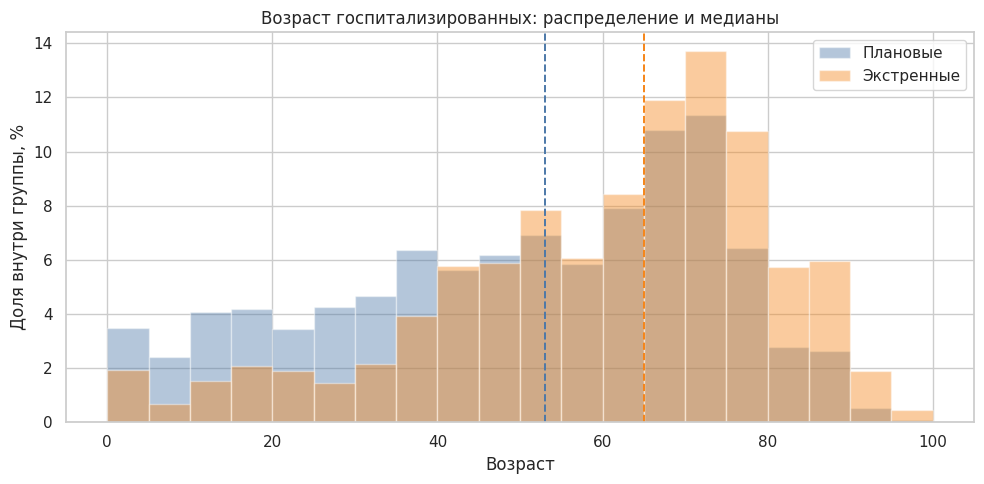

In [80]:
age_summary = (
    combined_hosps
    .groupby('group', observed=True)['age']
    .agg(
        n='count',
        mean_age='mean',
        median_age='median',
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
        min_age='min',
        max_age='max'
    )
    .round(1)
    .reset_index()
)

display(age_summary)

colors = globals().get('plot_colors', {'Плановые': '#4C78A8', 'Экстренные': '#F58518'})
fig, ax = plt.subplots(figsize=(10, 5))
age_bins = np.arange(0, 105, 5)

for group in ['Плановые', 'Экстренные']:
    data = combined_hosps.loc[combined_hosps['group'] == group, 'age'].dropna()
    ax.hist(
        data, bins=age_bins, weights=np.ones(len(data)) / len(data) * 100,
        alpha=0.42, color=colors[group], label=group
    )
    ax.axvline(data.median(), color=colors[group], linestyle='--', linewidth=1.4)

ax.set_title('Возраст госпитализированных: распределение и медианы')
ax.set_xlabel('Возраст')
ax.set_ylabel('Доля внутри группы, %')
ax.legend()
plt.tight_layout()
plt.show()

Видно, что экстренная группа пациентов более возрастная. Доля пациентов моложе 50 больше в плановой группе, а доля пациентов старше 50 больше в экстренной группе. Медианный возраст экстренных пациентов - 65, что на 12 лет больше медианного возраста плановых пациентов. Из-за ассиметрии в данных медиана информативнее среднего значения.

Поскольку экстренные пациенты значительно старше, часть повышенной летальности может объясняться именно возрастом.

### 8.3 Сроки летальных исходов после госпитализации

In [81]:
# расчет поля число дней в стационаре до летального исхода
mask = combined_hosps['outcome'] == 'Умер'
combined_hosps.loc[mask, 'days_to_death'] = (
    combined_hosps.loc[mask, 'death_date'] - combined_hosps.loc[mask, 'hosp_date']
).dt.days

In [82]:
combined_hosps['days_to_death'].max()

100.0

,group,median_days_to_death,q25_days_to_death,q75_days_to_death
0,Плановые,9.5,2.8,16.2
1,Экстренные,4.0,1.0,10.0


,days_after_hosp,group,deaths,share_pct_of_admissions
0,0,Плановые,6,0.2
1,0,Экстренные,16,0.8
2,3,Плановые,34,0.9
3,3,Экстренные,72,3.8
4,7,Плановые,56,1.5
5,7,Экстренные,100,5.2
6,30,Плановые,117,3.2
7,30,Экстренные,145,7.6
8,100,Плановые,124,3.4
9,100,Экстренные,148,7.7


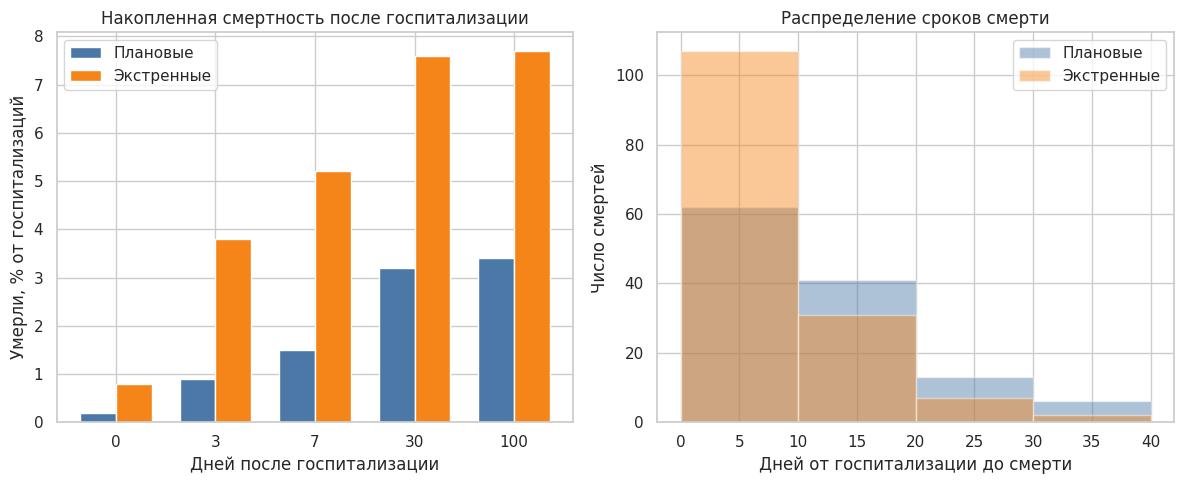

In [83]:

mortality_summary = (
    combined_hosps
    .groupby('group', observed=True)
    .agg(
        median_days_to_death=('days_to_death', 'median'),
        q25_days_to_death=('days_to_death', lambda x: x.dropna().quantile(0.25)),
        q75_days_to_death=('days_to_death', lambda x: x.dropna().quantile(0.75)),
    )
    .round(1)
    .reset_index()
)

window_rows = []
for days in [0, 3, 7, 30, 100]:
    for group, part in combined_hosps.groupby('group', observed=True):
        window_rows.append({
            'days_after_hosp': days,
            'group': group,
            'deaths': int(part['days_to_death'].between(0, days).sum()),
            'share_pct_of_admissions': round(part['days_to_death'].between(0, days).mean() * 100, 1),
        })
death_windows = pd.DataFrame(window_rows)

display(mortality_summary)
display(death_windows)

colors = globals().get('plot_colors', {'Плановые': '#4C78A8', 'Экстренные': '#F58518'})
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
window_pivot = death_windows.pivot(
    index='days_after_hosp', columns='group', values='share_pct_of_admissions'
)
x = np.arange(len(window_pivot.index))
width = 0.36
axes[0].bar(x - width/2, window_pivot['Плановые'], width=width, color=colors['Плановые'], label='Плановые')
axes[0].bar(x + width/2, window_pivot['Экстренные'], width=width, color=colors['Экстренные'], label='Экстренные')
axes[0].set_xticks(x)
axes[0].set_xticklabels(window_pivot.index.astype(str))
axes[0].set_xlabel('Дней после госпитализации')
axes[0].set_ylabel('Умерли, % от госпитализаций')
axes[0].set_title('Накопленная смертность после госпитализации')
axes[0].legend()

for group in ['Плановые', 'Экстренные']:
    data = combined_hosps.loc[
        (combined_hosps['group'] == group) &
        (combined_hosps['days_to_death'].notna()) &
        (combined_hosps['days_to_death'] <= 365),
        'days_to_death'
    ]
    axes[1].hist(data, bins=np.arange(0, 50, 10), alpha=0.45, color=colors[group], label=group)
axes[1].set_xlabel('Дней от госпитализации до смерти')
axes[1].set_ylabel('Число смертей')
axes[1].set_title('Распределение сроков смерти')
axes[1].legend()

plt.tight_layout()
plt.show()


Экстренные госпитализации старше: медиана 65 лет против 53. Класс IX (болезни системы кровообращения) занимает 35.6% экстренных и 22.0% плановых госпитализаций. Смертность после госпитализации выше в экстренной группе: 21.7% против 12.3%; медианный срок до смерти короче: 30 дней против 50.


### 8.4 Структура госпитализаций по классам МКБ-10

,group,icd_chapter,class_name,n,share_pct
0,Плановые,I00-I99,Болезни системы кровообращения,796,22.0
1,Плановые,O00-O99,"Беременность, роды и послеродовой период",426,11.8
2,Плановые,J00-J99,Болезни органов дыхания,398,11.0
3,Плановые,K00-K93,Болезни органов пищеварения,356,9.8
4,Плановые,M00-M99,Болезни костно-мышечной системы,331,9.2
5,Плановые,N00-N99,Болезни мочеполовой системы,323,8.9
6,Плановые,S00-T98,Травмы и отравления,277,7.7
7,Плановые,D50-D89,Болезни крови и иммунные нарушения,123,3.4
8,Плановые,F00-F99,Психические расстройства,121,3.3
9,Плановые,C00-D48,Новообразования,100,2.8


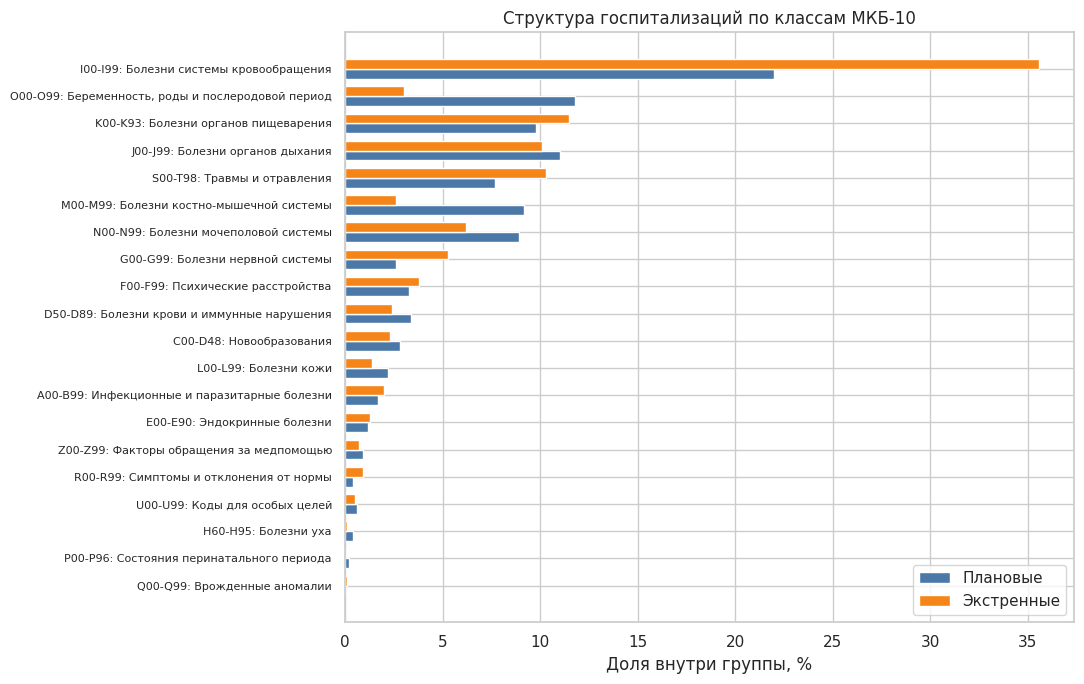

In [84]:
combined_hosps['icd_chapter'] = combined_hosps['diagnosis'].apply(icd_chapter)
icd_summary = (
    combined_hosps
    .groupby(['group', 'icd_chapter'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)
icd_summary['share_pct'] = (
    icd_summary['n'] / icd_summary.groupby('group', observed=True)['n'].transform('sum') * 100
).round(1)
icd_summary['class_name'] = icd_summary['icd_chapter'].map(icd_names)
icd_top = (
    icd_summary
    .sort_values(['group', 'share_pct'], ascending=[True, False])
    .groupby('group', observed=True)
    .head(10)
    [['group', 'icd_chapter', 'class_name', 'n', 'share_pct']]
    .reset_index(drop=True)
)

display(icd_top)

colors = globals().get('plot_colors', {'Плановые': '#4C78A8', 'Экстренные': '#F58518'})
icd_pivot = (
    icd_summary
    .pivot_table(index='icd_chapter', columns='group', values='share_pct', fill_value=0, observed=True)
)
icd_pivot['max_share'] = icd_pivot[['Плановые', 'Экстренные']].max(axis=1)
icd_pivot = icd_pivot.sort_values('max_share')
y = np.arange(len(icd_pivot))
labels = [f'{idx}: {icd_names.get(idx, idx)}' for idx in icd_pivot.index]

fig, ax = plt.subplots(figsize=(11, max(6, len(labels) * 0.35)))

bar_h = 0.36
ax.barh(y - bar_h/2, icd_pivot['Плановые'], height=bar_h, color=colors['Плановые'], label='Плановые')
ax.barh(y + bar_h/2, icd_pivot['Экстренные'], height=bar_h, color=colors['Экстренные'], label='Экстренные')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Доля внутри группы, %')
ax.set_title('Структура госпитализаций по классам МКБ-10')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

Болезни системы кровообращения — главный профиль госпитализаций, как экстренных (36%), так и плановых (22%).

12% плановых госпитализаций приходится на роды и беременность. Наличие большого числа молодых женщин в этой группе частично снижает средний возраст и летальность плановых госпитализаций.

В плановых госпитализациях больше хронической патологии (M, N, J). Это заболевания, которые часто требуют обследования, операций или длительного лечения, но не обязательно связаны с острым жизнеугрожающим состоянием.

Экстренные госпитализации чаще связаны с острыми состояниями (I, S, G). Эти классы часто сопровождаются внезапным ухудшением состояния и требуют срочной госпитализации.

Видно, что плановые и экстренные группы заметно отличаются. Плановые моложе, преобладают хронические, относительно стабильные состояния. Экстренные старше, больше острых, угрожающих жизни состояний. Поэтому сравнивать летальность "в лоб" не совсем корректно: значительная часть разницы объясняется различиями в возрасте и диагнозах пациентов.

## 9. Детализация госпитализаций `I00-I99`

Ниже структура госпитализаций с болезнями системы кровообращения: сначала по подгруппам МКБ-10 внутри `I00-I99`, затем по самым частым трехзначным кодам. Расчет сохраняет раздельное сравнение плановых и экстренных госпитализаций.

,group,icd_i_group,icd_i_name,n,share_pct_i00_i99,share_pct_all_hosps
0,Плановые,I10-I15,"Болезни, характеризующиеся повышенным кровяным...",159,20.0,4.4
1,Плановые,I20-I25,Ишемические болезни сердца,100,12.6,2.8
2,Плановые,I26-I28,Легочное сердце и нарушения легочного кровообр...,7,0.9,0.2
3,Плановые,I30-I52,Другие болезни сердца,129,16.2,3.6
4,Плановые,I60-I69,Цереброваскулярные болезни,265,33.3,7.3
5,Плановые,I70-I79,"Болезни артерий, артериол и капилляров",62,7.8,1.7
6,Плановые,I80-I89,"Болезни вен, лимфатических сосудов и лимфатиче...",74,9.3,2.0
7,Экстренные,I05-I09,Хронические ревматические болезни сердца,1,0.1,0.1
8,Экстренные,I10-I15,"Болезни, характеризующиеся повышенным кровяным...",150,22.0,7.8
9,Экстренные,I20-I25,Ишемические болезни сердца,143,21.0,7.5


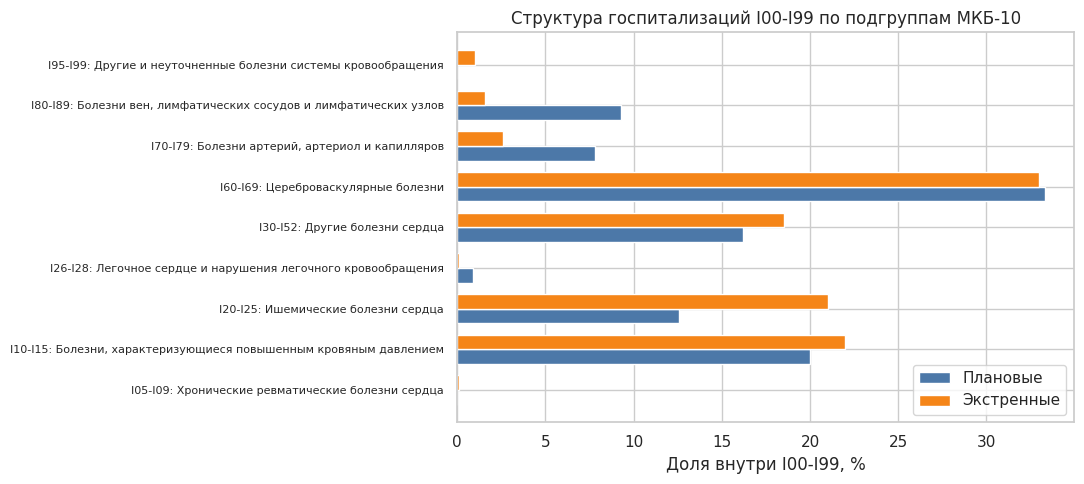

In [85]:
def icd_code3(diagnosis):
    match = re.search(r'([A-Z])\s*(\d{2})', str(diagnosis).upper())

    if not match:
        return 'Unknown'

    return f'{match.group(1)}{int(match.group(2)):02d}'


i_subgroup_ranges = [
    ('I00-I02', 0, 2, 'Острая ревматическая лихорадка'),
    ('I05-I09', 5, 9, 'Хронические ревматические болезни сердца'),
    ('I10-I15', 10, 15, 'Болезни, характеризующиеся повышенным кровяным давлением'),
    ('I20-I25', 20, 25, 'Ишемические болезни сердца'),
    ('I26-I28', 26, 28, 'Легочное сердце и нарушения легочного кровообращения'),
    ('I30-I52', 30, 52, 'Другие болезни сердца'),
    ('I60-I69', 60, 69, 'Цереброваскулярные болезни'),
    ('I70-I79', 70, 79, 'Болезни артерий, артериол и капилляров'),
    ('I80-I89', 80, 89, 'Болезни вен, лимфатических сосудов и лимфатических узлов'),
    ('I90-I94', 90, 94, 'Прочие коды I90-I94'),
    ('I95-I99', 95, 99, 'Другие и неуточненные болезни системы кровообращения'),
]

i_subgroup_order = [item[0] for item in i_subgroup_ranges] + ['Unknown']
i_subgroup_names = {item[0]: item[3] for item in i_subgroup_ranges}
i_subgroup_names['Unknown'] = 'Не распознано'
i_subgroup_sort = {group: i for i, group in enumerate(i_subgroup_order)}


def icd_i_subgroup(code):
    match = re.match(r'I(\d{2})', str(code).upper())

    if not match:
        return 'Unknown'

    num = int(match.group(1))
    for group, start, end, _ in i_subgroup_ranges:
        if start <= num <= end:
            return group

    return 'Unknown'


if 'icd_chapter' not in combined_hosps.columns:
    combined_hosps['icd_chapter'] = combined_hosps['diagnosis'].apply(icd_chapter)

i00_i99_hosps = combined_hosps.loc[combined_hosps['icd_chapter'] == 'I00-I99'].copy()
i00_i99_hosps['icd_code3'] = i00_i99_hosps['diagnosis'].apply(icd_code3)
i00_i99_hosps['icd_i_group'] = i00_i99_hosps['icd_code3'].apply(icd_i_subgroup)
i00_i99_hosps['icd_i_name'] = i00_i99_hosps['icd_i_group'].map(i_subgroup_names)

if i00_i99_hosps.empty:
    print('В combined_hosps нет госпитализаций с icd_chapter == I00-I99')
else:
    all_hosps_by_group = combined_hosps.groupby('group', observed=True).size()
    i_hosps_by_group = i00_i99_hosps.groupby('group', observed=True).size()

    i00_i99_structure = (
        i00_i99_hosps
        .groupby(['group', 'icd_i_group', 'icd_i_name'], observed=True)
        .size()
        .rename('n')
        .reset_index()
    )
    i_totals = i00_i99_structure['group'].astype('object').map(i_hosps_by_group).astype(float)
    all_totals = i00_i99_structure['group'].astype('object').map(all_hosps_by_group).astype(float)
    i00_i99_structure['share_pct_i00_i99'] = (i00_i99_structure['n'] / i_totals * 100).round(1)
    i00_i99_structure['share_pct_all_hosps'] = (i00_i99_structure['n'] / all_totals * 100).round(1)
    i00_i99_structure['sort_order'] = i00_i99_structure['icd_i_group'].map(i_subgroup_sort)
    i00_i99_structure = (
        i00_i99_structure
        .sort_values(['group', 'sort_order'])
        .drop(columns='sort_order')
        .reset_index(drop=True)
    )

    display(i00_i99_structure)

    colors = globals().get('plot_colors', {'Плановые': '#4C78A8', 'Экстренные': '#F58518'})
    i_plot = (
        i00_i99_structure
        .pivot_table(
            index='icd_i_group', columns='group', values='share_pct_i00_i99',
            fill_value=0, observed=True
        )
        .reindex([group for group in i_subgroup_order if group in i00_i99_structure['icd_i_group'].unique()])
    )

    for group in ['Плановые', 'Экстренные']:
        if group not in i_plot.columns:
            i_plot[group] = 0

    y = np.arange(len(i_plot))
    labels = [f'{idx}: {i_subgroup_names.get(idx, idx)}' for idx in i_plot.index]

    fig, ax = plt.subplots(figsize=(11, max(5, len(labels) * 0.45)))
    bar_h = 0.36
    ax.barh(y - bar_h/2, i_plot['Плановые'], height=bar_h, color=colors['Плановые'], label='Плановые')
    ax.barh(y + bar_h/2, i_plot['Экстренные'], height=bar_h, color=colors['Экстренные'], label='Экстренные')

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Доля внутри I00-I99, %')
    ax.set_title('Структура госпитализаций I00-I99 по подгруппам МКБ-10')
    ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()


Цереброваскулярные болезни занимают первое место среди плановых и экстренных госпитализаций (33%).
Также значительную долю (более 20%) занимают ишемические болезни сердца и гипертония. Ишемические болезни чаще лечат экстренно.
Болезни группы I70-89 в основном лечат планово, экстренных случаев гораздо меньше.

In [105]:
if i00_i99_hosps.empty:
    print('В combined_hosps нет госпитализаций с icd_chapter == I00-I99')
else:
    all_hosps_by_group = combined_hosps.groupby('group', observed=True).size()
    i_hosps_by_group = i00_i99_hosps.groupby('group', observed=True).size()

    i00_i99_code_structure = (
        i00_i99_hosps
        .groupby(['group', 'icd_code3'], observed=True)
        .agg(
            n=('diagnosis', 'size'),
            diagnosis=('diagnosis', lambda s: s.value_counts().index[0])
        )
        .reset_index()
    )
    i_code_totals = i00_i99_code_structure['group'].astype('object').map(i_hosps_by_group).astype(float)
    all_code_totals = i00_i99_code_structure['group'].astype('object').map(all_hosps_by_group).astype(float)
    i00_i99_code_structure['share_pct_i00_i99'] = (i00_i99_code_structure['n'] / i_code_totals * 100).round(1)
    i00_i99_code_structure['share_pct_all_hosps'] = (i00_i99_code_structure['n'] / all_code_totals * 100).round(1)

    i00_i99_code_top = (
        i00_i99_code_structure
        .sort_values(['group', 'n'], ascending=[True, False])
        .groupby('group', observed=True)
        .head(5)
        .reset_index(drop=True)
    )

    display(i00_i99_code_top)


,group,icd_code3,n,diagnosis,share_pct_i00_i99,share_pct_all_hosps
0,Плановые,I67,192,I67.8. Другие уточненные поражения сосудов мозга,24.1,5.3
1,Плановые,I11,158,I11.9. Гипертензивная [гипертоническая] болезн...,19.8,4.4
2,Плановые,I48,91,I48.0. Пароксизмальная форма фибрилляции предс...,11.4,2.5
3,Плановые,I70,61,I70.2. Атеросклероз артерий конечностей,7.7,1.7
4,Плановые,I63,60,"I63.5. Инфаркт мозга, вызванный неуточненной з...",7.5,1.7
5,Экстренные,I63,152,"I63.5. Инфаркт мозга, вызванный неуточненной з...",22.3,7.9
6,Экстренные,I11,150,I11.9. Гипертензивная [гипертоническая] болезн...,22.0,7.8
7,Экстренные,I48,89,I48.0. Пароксизмальная форма фибрилляции предс...,13.0,4.6
8,Экстренные,I67,65,I67.8. Другие уточненные поражения сосудов мозга,9.5,3.4
9,Экстренные,I25,63,I25.8. Другие формы хронической ишемической бо...,9.2,3.3


## 10. Сравнение длительности пребывания в стационаре после плановой и экстренной госпитализации

Есть ли разница в количестве дней лечения в стационаре между плановыми и экстренными пациентами?

In [87]:
print(f'Повторные плановые госпитализации - {planned_hosps['patient_id'].duplicated().sum()}')
print(f'Повторные экстренные госпитализации - {emergency_admissions['patient_id'].duplicated().sum()}')

Повторные плановые госпитализации - 499
Повторные экстренные госпитализации - 272


Поскольку сравниваю группы пациентов, нужно избавиться от повторных госпитализаций. Для пациентов, кто госпитализировался больше 1 раза, возьму среднее значение койко-дней по всем случаям.

In [88]:
planned_hosps.head(1)

,patient_id,age,death_date,hosp_date,end_date,diagnosis,department,profile,hospital_days,location,outcome,icd_group,icd_name
0,6c2df81a7382fdf0,75,NaT,2024-12-23,2025-01-01,I48.0. Пароксизмальная форма фибрилляции предс...,Кардиология стац.,Кардиология,9,стационар,Выписан,I00-I99,Болезни системы кровообращения


In [89]:
ph_patients = planned_hosps.groupby(['patient_id', 'age'])['hospital_days'].mean().reset_index()
ea_patients = emergency_admissions.groupby(['patient_id', 'age'])['hospital_days'].mean().reset_index()

In [90]:
print(f'Плановые пациенты - {ph_patients.shape[0]}')
print(f'Экстренные пациенты - {ea_patients.shape[0]}')

Плановые пациенты - 3121
Экстренные пациенты - 1645


In [91]:
ph_decribe = ph_patients['hospital_days'].describe()
ea_describe = ea_patients['hospital_days'].describe()

phea_describe = pd.concat([ph_decribe, ea_describe], axis=1)

phea_describe.columns = ['Плановая длительность', 'Экстренная длительность']

display(phea_describe)

,Плановая длительность,Экстренная длительность
count,3121.000000,1645.000000
mean,9.146315,9.520780
std,6.699441,6.772128
min,1.000000,1.000000
25%,5.000000,5.000000
50%,8.000000,8.500000
75%,11.000000,12.000000
max,101.000000,73.000000


Среднее и стандартное отклонение практически равны. Разницы, скорее всего, нет. Проведу формальную проверку с помощью стат теста.

Чтобы выбрать стат критерий для сравнения пациентов, нужно узнать зависимы ли выборки. Смотрю, есть ли такие пациенты, кто находится в обеих группах.

In [92]:
phea_patients_count = ph_patients['patient_id'].isin(ea_patients['patient_id']).sum()
phea_patients_count

np.int64(309)

309 общих пациентов. Поскольку выборки зависимы частично, парный t-тест применять нельзя. В таком случае сделаю выборки независимыми путем исключения из них общих пациентов и применю t-тест Стьюдента.

In [93]:
print(f'Доля общих пациентов в плановой группе - {round(phea_patients_count / ph_patients.shape[0] * 100, 1)}')
print(f'Доля общих пациентов в экстренной группе - {round(phea_patients_count / ea_patients.shape[0] * 100, 1)}')

Доля общих пациентов в плановой группе - 9.9
Доля общих пациентов в экстренной группе - 18.8


Плановая выборка потеряет 10% данных, а экстренная выборка - 19%. Хотя 19% дововльно большая потеря, но если структура выборки отстанется той же, то это допустимо. Проверю структуру выборки по возрасту (единственный доступный признак).

In [94]:
only_ph = ph_patients[~ph_patients['patient_id'].isin(ea_patients['patient_id'])]
only_ea = ea_patients[~ea_patients['patient_id'].isin(ph_patients['patient_id'])]

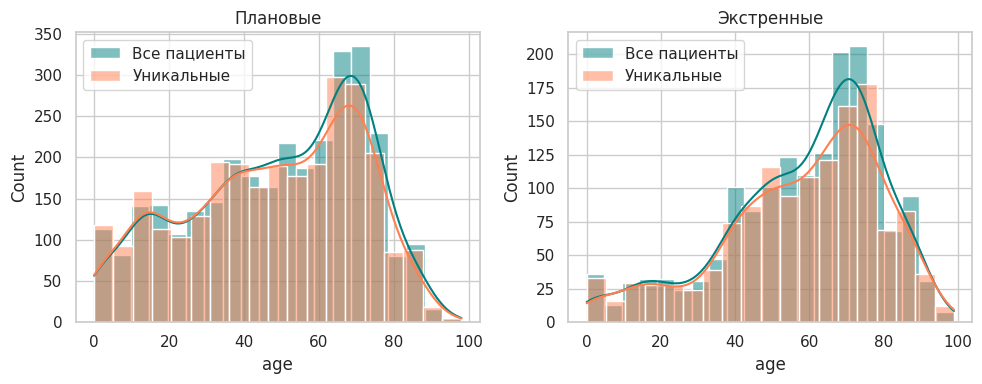

In [95]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

data_pairs = [
    (ph_patients, only_ph, axs[0], 'Плановые'),
    (ea_patients, only_ea, axs[1], 'Экстренные')
]

for i, (full_df, unique_df, ax, title) in enumerate(data_pairs):
    sns.histplot(full_df['age'], kde=True, ax=ax, color='teal', label='Все пациенты')
    sns.histplot(unique_df['age'], kde=True, ax=ax, color='coral', label='Уникальные')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

В обеих группах после удаление общих пациентов распределение по возрасту сохраняет исходную форму.

Выборки достаточно большие, поэтому, согласно ЦПТ, распределение выборочного среднего будет стремиться к нормальному, независимо от распределения исходных данных. Таким образом, можно применять t-test Уэлча, который не предполагает равенства дисперсий.

In [97]:
statistic_welch, p_value_welch = ttest_ind(only_ph['hospital_days'], only_ea['hospital_days'], equal_var=False)
print("\n=== T-тест Уэлча ===")
print(f"t-статистика: {statistic_welch:.3f}")
print(f"P-значение: {p_value_welch:.6f}")
if p_value_welch < 0.05:
    print("Вывод: Различия между группами статистически значимы (отвергаем H0)")
else:
    print("Вывод: Нет оснований утверждать о значимых различиях между группами")


=== T-тест Уэлча ===
t-статистика: 0.387
P-значение: 0.699147
Вывод: Нет оснований утверждать о значимых различиях между группами


У плановых и экстренных пациентов длительность лечения в стационаре не различается.

In [99]:
# Уровень значимости (альфа)
alpha = 0.05

# Описательная статистика нужна для расчета стандартной ошибки
n1, n2 = len(only_ph['hospital_days']), len(only_ea['hospital_days'])
mean1, mean2 = only_ph['hospital_days'].mean(), only_ea['hospital_days'].mean()
std1, std2 = np.std(only_ph['hospital_days'], ddof=1), np.std(only_ea['hospital_days'], ddof=1) # ddof=1 для несмещенной оценки

# Рассчитываем стандартную ошибку разности средних
standard_error = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Находим критическое значение t-распределения
df = n1 + n2 - 2 # Приближение для оценки квантиля
t_critical = stats.t.ppf(1 - alpha/2, df=df)

# Рассчитываем доверительный интервал
diff_means = mean1 - mean2 # Разность средних
margin_of_error = t_critical * standard_error

ci_lower = diff_means - margin_of_error
ci_upper = diff_means + margin_of_error

print("\n--- Результаты ---")
print(f"Разность средних (ph - ea): {round(diff_means, 3)}")
print(f"95% Доверительный интервал: [{round(ci_lower, 3)}, {round(ci_upper, 3)}]")


--- Результаты ---
Разность средних (ph - ea): 0.082
95% Доверительный интервал: [-0.335, 0.5]


С 95% уверенностью можно утверждать, разность длительности лечения у плановых и экстренных пациентов находится в диапазоне от -0.335 до 0.5 койко-дней. Интервал включает в себя 0, а значит, можно говорить, что средние не различаются.

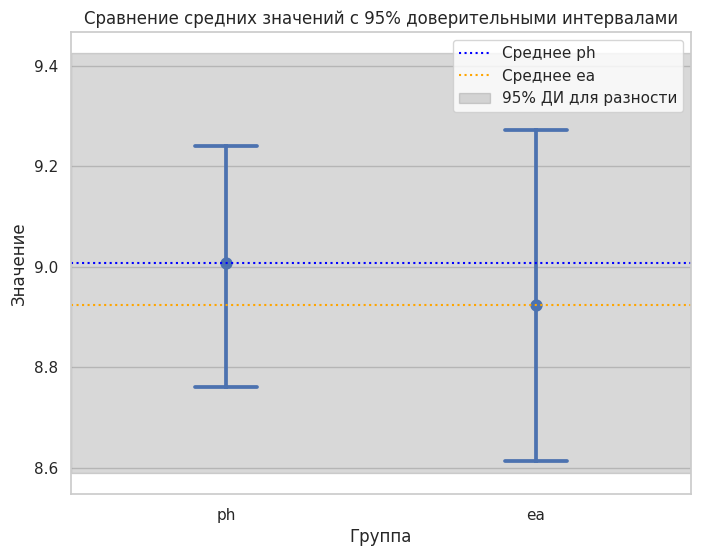

In [101]:
plt.figure(figsize=(8, 6))

# Создаем DataFrame для seaborn
data = pd.DataFrame({
    'Значение': np.concatenate([only_ph['hospital_days'], only_ea['hospital_days']]),
    'Группа': ['ph'] * len(only_ph['hospital_days']) + ['ea'] * len(only_ea['hospital_days'])
})

# Визуализируем распределения и точечные оценки средних
sns.pointplot(data=data, x='Группа', y='Значение', errorbar=('ci', 95), linestyle='none', capsize=0.2)
plt.title('Сравнение средних значений с 95% доверительными интервалами')
plt.ylabel('Значение')
plt.xlabel('Группа')

# Добавляем на график наш рассчитанный интервал разности
plt.axhline(y=mean1, color='blue', linestyle=':', label='Среднее ph')
plt.axhline(y=mean2, color='orange', linestyle=':', label='Среднее ea')
plt.axhspan(ci_lower + mean2, ci_upper + mean2, color='grey', alpha=0.3, label='95% ДИ для разности')
plt.legend()
plt.show()

ДИ плановых пациентов (ph) попадает внутрь этой серой зоны, значит, разница между средними статистически не значима.

## 11. Итоговые выводы

Анализ показывает, что экстренная госпитализация связана не только с фактом вызова СМП, но и с возрастом пациента, классом заболевания и предшествующими контактами с системой здравоохранения.

1. Экстренные госпитализации составляют существенную часть нагрузки круглосуточного стационара: в текущем расчете их доля составляет около 37%.
2. Экстренные пациенты заметно старше плановых: медианный возраст 65 лет против 53 лет. Поэтому сравнение исходов между плановыми и экстренными госпитализациями требует учета возраста.
3. Болезни системы кровообращения (`I00-I99`) являются ключевой группой для стационара: они занимают около 36% экстренных и 22% плановых госпитализаций. Цереброваскулярные, ишемические болезни, а также гипертония занимают основную долю в структуре (`I00-I99`).
4. У пациентов с `I00-I99` индивидуальный риск экстренной госпитализации после контакта с поликлиникой не максимальный, но абсолютное число таких пациентов большое. Поэтому группа важна для профилактики и маршрутизации.
5. У 16% экстренных госпитализаций перед событием было обращение в поликлинику за 5 дней или меньше по тому же классу заболеваний. Это потенциальное окно для более раннего выявления ухудшения состояния.
6. Отдельно выявлена группа пациентов, у которых за 5 дней до экстренной госпитализации уже был вызов СМП по тому же диагнозу без госпитализации. Эта доля составляет 4,4% экстренных госпитализаций и может указывать на случаи, где требовалась более внимательная маршрутизация или наблюдение.
7. Нагрузка имеет сезонность: по всем видам медицинской помощи она снижается летом и повышается в осенне-зимний период и в конце года.
8. Летальность среди экстренных госпитализаций выше, чем среди плановых: 7,7% против 3,4%. Однако это сравнение нельзя интерпретировать как прямую оценку качества помощи, потому что группы различаются по возрасту и структуре диагнозов.

Главный практический вывод: для снижения экстренной госпитализации наиболее перспективно выделять пациентов высокого риска после контакта с поликлиникой или СМП, особенно среди пожилых пациентов и пациентов с сердечно-сосудистыми заболеваниями.